In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

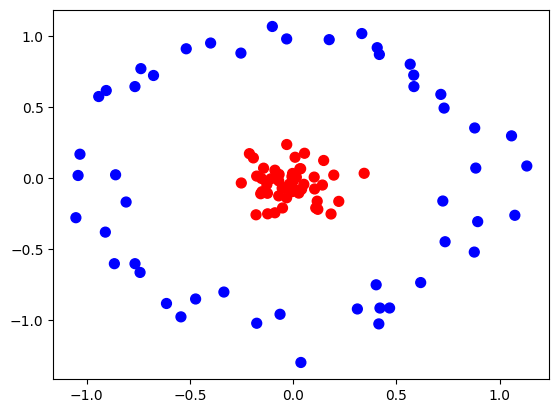

In [4]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20)

In [7]:
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [8]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.6

In [23]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                 stop = X_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1, 
                                 stop = X_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], color = zero_one_colourmap(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

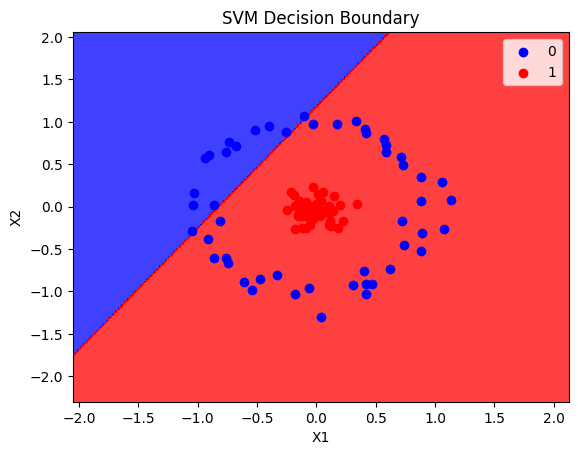

In [24]:
plot_decision_boundary(X, y, classifier)

In [11]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

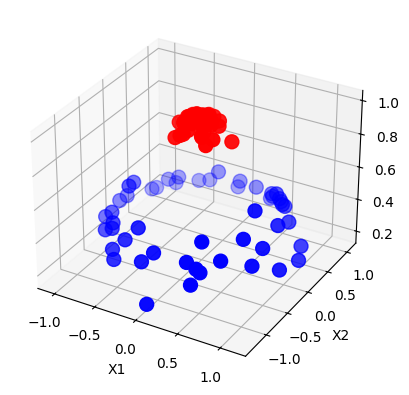

In [12]:
plot_3d_plot(X,y)

In [13]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [14]:
accuracy_score(y_test,y_pred)

1.0

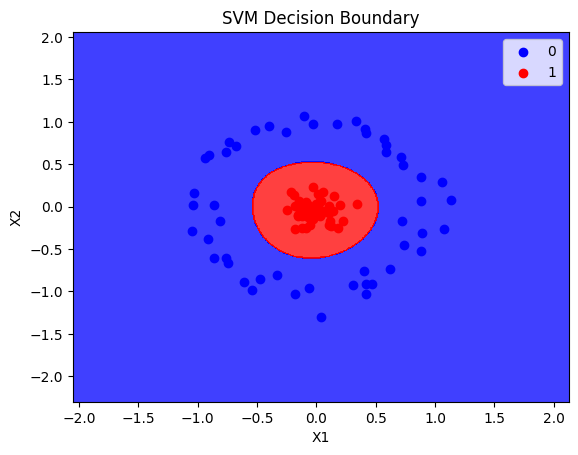

In [25]:
plot_decision_boundary(X,y, rbf_classifier)

In [16]:
poly_classifier = SVC(kernel='poly',degree=2)
poly_classifier.fit(X_train,y_train)
y_pred = poly_classifier.predict(X_test)

In [17]:
accuracy_score(y_test,y_pred)

1.0

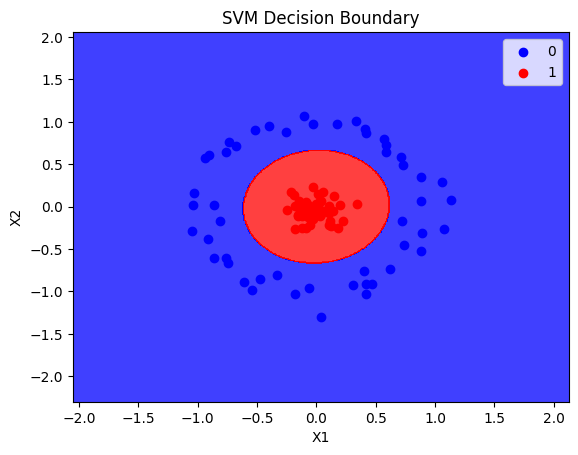

In [26]:
plot_decision_boundary(X,y,poly_classifier)

In [20]:
X

array([[ 4.67510252e-01, -9.17602734e-01],
       [ 5.21779825e-02, -4.64735584e-02],
       [-1.50822034e-01, -9.86574562e-02],
       [-3.99349825e-01,  9.48468775e-01],
       [-7.65654894e-01, -6.05632941e-01],
       [ 5.67252532e-01,  7.99303207e-01],
       [ 4.02419694e-01, -7.54238753e-01],
       [-1.04132973e+00,  1.56872018e-02],
       [ 1.16820522e-01, -1.65334739e-01],
       [ 1.07411246e+00, -2.64691526e-01],
       [-7.65900727e-01,  6.41731887e-01],
       [-4.45921575e-03, -9.49812893e-02],
       [-8.08736414e-01, -1.71311082e-01],
       [-1.24225689e-01, -1.09723232e-01],
       [-6.96098857e-02, -2.21408758e-02],
       [-3.12961433e-02, -1.41454495e-01],
       [ 1.02252314e-01,  4.21929736e-03],
       [ 4.15343710e-01, -1.02960339e+00],
       [ 7.15691122e-01,  5.86782734e-01],
       [-6.13160057e-01, -8.85910115e-01],
       [-5.17490394e-01,  9.08026581e-01],
       [-3.07431133e-02,  2.33773989e-01],
       [-8.78789613e-02,  5.28048204e-02],
       [-5.

In [21]:
X_new = np.exp(-(X**2))

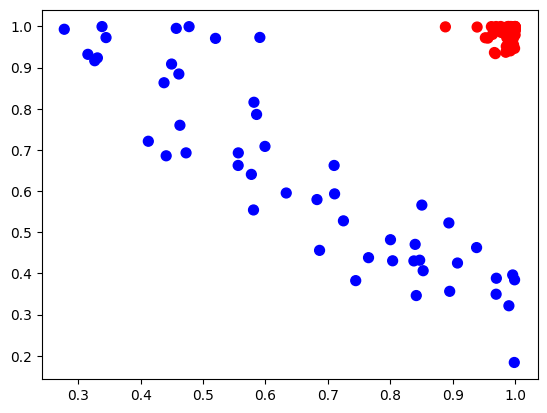

In [22]:
plt.scatter(X_new[:,0], X_new[:,1],c=y, s=50, cmap='bwr')